In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0
All libraries loaded ✅


Dataset Loading

In [ ]:
df = pd.read_csv('final_data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (4521, 28)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'previous_contacted', 'previous_success', 'age_group', 'total_contacts', 'contact_pressure', 'high_contact_flag', 'never_contacted_before', 'recent_contact', 'pdays_bucket', 'prev_success', 'prev_contact_flag', 'engagement_score']


,age,job,marital,education,default,balance,housing,loan,contact,day,...,age_group,total_contacts,contact_pressure,high_contact_flag,never_contacted_before,recent_contact,pdays_bucket,prev_success,prev_contact_flag,engagement_score
0,30,unemployed,married,primary,0,0.282211,0,0,cellular,19,...,Young,1,1.0,0,1,0,never,0,0,0
1,33,services,married,secondary,0,1.209846,1,1,cellular,11,...,Adult,5,0.2,0,0,0,never,0,1,0
2,35,management,single,tertiary,0,0.130429,1,0,cellular,16,...,Adult,2,0.5,0,0,0,never,0,1,0
3,30,management,married,tertiary,0,0.174936,1,1,unknown,3,...,Young,4,4.0,1,1,0,never,0,0,0
4,59,blue-collar,married,secondary,0,-0.445382,1,0,unknown,5,...,Senior,1,1.0,0,1,0,never,0,0,0


Visualization for class imbalance

Target Distribution:
y
0    4000
1     521
Name: count, dtype: int64

Imbalance Ratio: 7.68:1


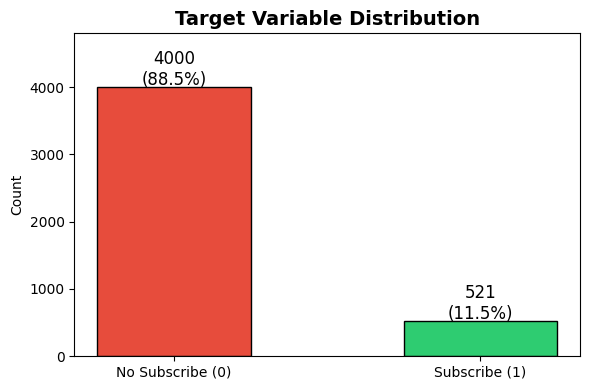

In [ ]:
print("Target Distribution:")
print(df['y'].value_counts())
print(f"\nImbalance Ratio: {df['y'].value_counts()[0] / df['y'].value_counts()[1]:.2f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['y'].value_counts()
bars = ax.bar(['No Subscribe (0)', 'Subscribe (1)'], counts.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=12)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 4800)
plt.tight_layout()
plt.show()

In [ ]:
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'age_group', 'pdays_bucket']

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Encoded columns:", cat_cols)
print("\nData types after encoding:")
print(df.dtypes)

Encoded columns: ['job', 'marital', 'education', 'contact', 'month', 'age_group', 'pdays_bucket']

Data types after encoding:
age                         int64
job                         int64
marital                     int64
education                   int64
default                     int64
balance                   float64
housing                     int64
loan                        int64
contact                     int64
day                         int64
month                       int64
duration                  float64
campaign                    int64
pdays                       int64
previous                    int64
y                           int64
previous_contacted          int64
previous_success            int64
age_group                   int64
total_contacts              int64
contact_pressure          float64
high_contact_flag           int64
never_contacted_before      int64
recent_contact              int64
pdays_bucket                int64
prev_success            

In [ ]:
smoX = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nTrain class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

Training set:   3616 samples
Test set:       905 samples

Train class balance: {0: 3199, 1: 417}
Test class balance:  {0: 801, 1: 104}


Handling data imbalance using SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

# scale_pos_weight: class 0 count / class 1 count (for XGBoost's internal handling)
scale_pos_weight = round(y_train.value_counts()[0] / y_train.value_counts()[1], 2)
print(f"\nscale_pos_weight (used in XGBoost): {scale_pos_weight}")

Before SMOTE: {0: 3199, 1: 417}
After  SMOTE: {0: 3199, 1: 3199}

scale_pos_weight (used in XGBoost): 7.67


XGBoost Classifier Model Implementation

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_sm, y_train_sm)
print("Model training complete ")

Model training complete ✅


In [ ]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)
f1   = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
ap   = average_precision_score(y_test, y_prob)

print("XGBoost — Model Performance")
print(f"Accuracy            : {acc:.4f}")
print(f"ROC-AUC Score       : {roc:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"Precision           : {prec:.4f}")
print(f"Recall (Sensitivity): {rec:.4f}")
print(f"Avg Precision (PR)  : {ap:.4f}")

XGBoost — Model Performance
Accuracy            : 0.7923
ROC-AUC Score       : 0.8774
F1 Score            : 0.4778
Precision           : 0.3359
Recall (Sensitivity): 0.8269
Avg Precision (PR)  : 0.4086


In [ ]:
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Subscribe', 'Subscribe']))

Detailed Classification Report:
              precision    recall  f1-score   support

No Subscribe       0.97      0.79      0.87       801
   Subscribe       0.34      0.83      0.48       104

    accuracy                           0.79       905
   macro avg       0.65      0.81      0.67       905
weighted avg       0.90      0.79      0.83       905



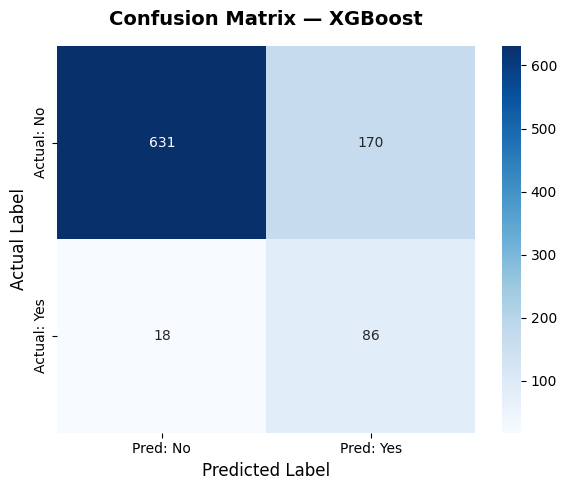


→ Model correctly identified 86 out of 104 actual subscribers (82.7% Recall)


In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'], ax=ax)
ax.set_title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n→ Model correctly identified {tp} out of {tp+fn} actual subscribers ({tp/(tp+fn)*100:.1f}% Recall)")

Visualizations

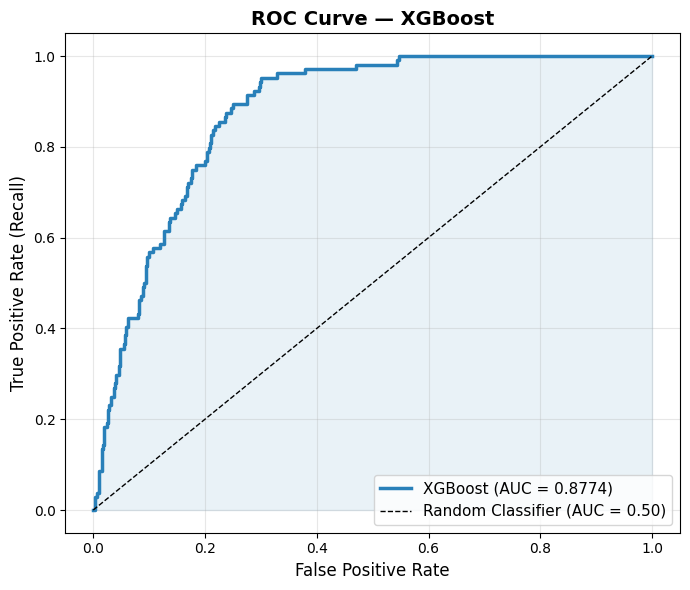

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2980b9', lw=2.5,
         label=f'XGBoost (AUC = {roc:.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

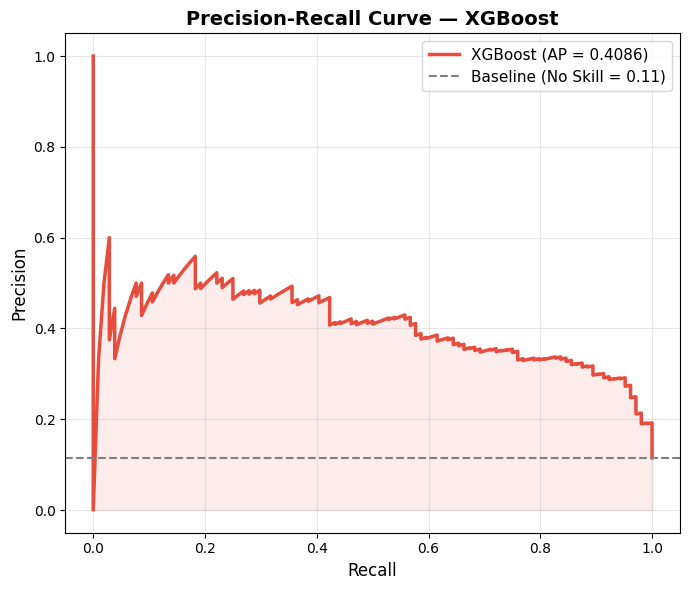

In [ ]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
baseline = y_test.sum() / len(y_test)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='#e74c3c', lw=2.5,
         label=f'XGBoost (AP = {ap:.4f})')
plt.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
            label=f'Baseline (No Skill = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color='#e74c3c')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

XgBoost Feature Importance: Ranked from most important to least important

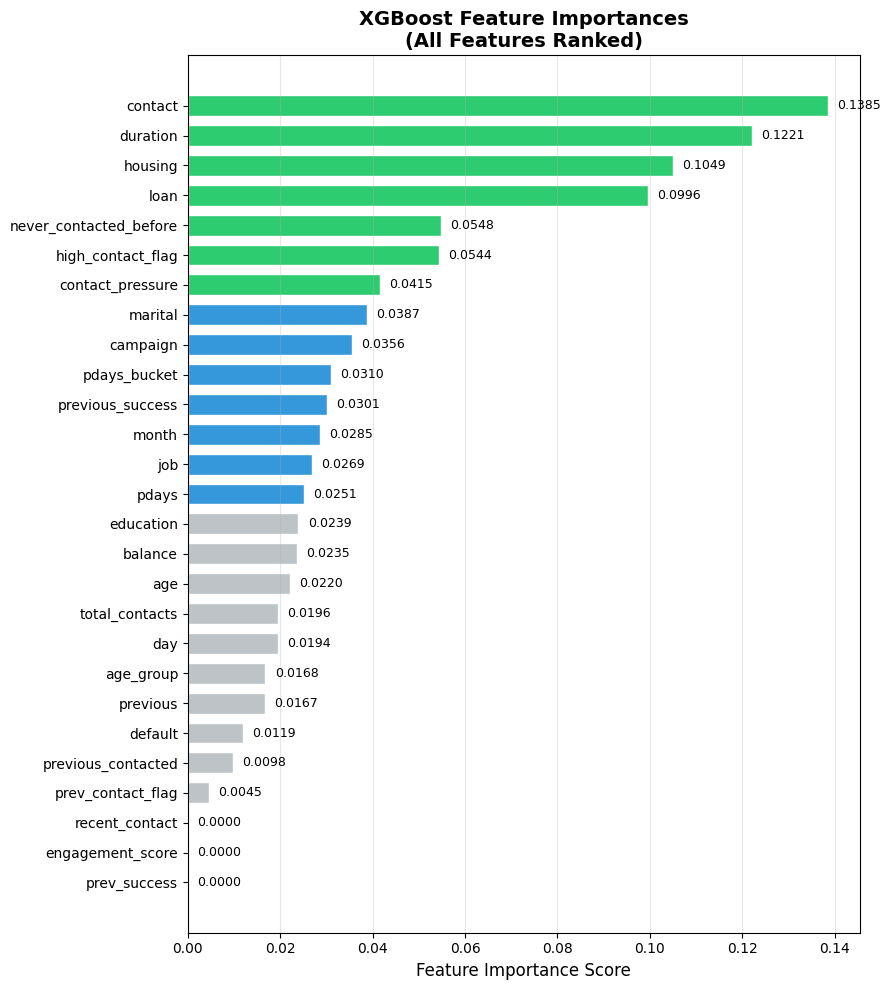


🔝 Top 10 Most Important Features:
contact                   0.138538
duration                  0.122103
housing                   0.104945
loan                      0.099607
never_contacted_before    0.054751
high_contact_flag         0.054380
contact_pressure          0.041488
marital                   0.038724
campaign                  0.035559
pdays_bucket              0.031044


In [ ]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['#2ecc71' if v >= feat_imp.quantile(0.75) else
          '#3498db' if v >= feat_imp.median() else
          '#bdc3c7' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('XGBoost Feature Importances\n(All Features Ranked)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔝 Top 10 Most Important Features:")
print(feat_imp.sort_values(ascending=False).head(10).to_string())

Default threshold (0.50) → F1: 0.4778
Optimal threshold (0.83) → F1: 0.4856


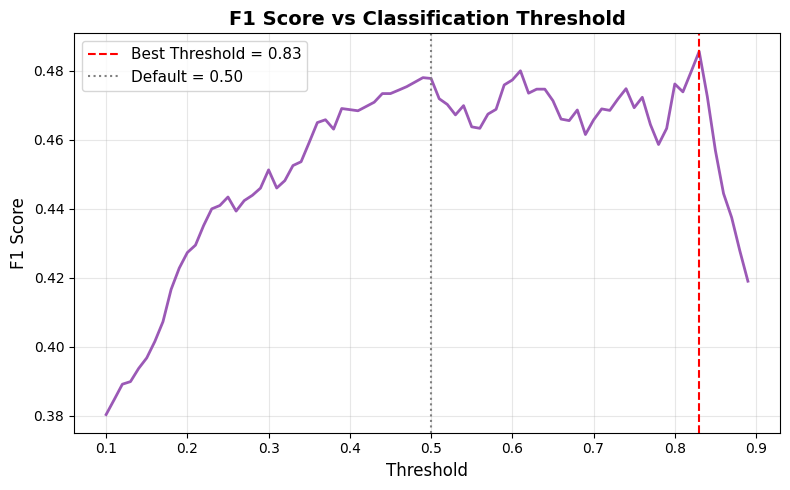


With Optimal Threshold (0.83):
              precision    recall  f1-score   support

No Subscribe       0.94      0.90      0.92       801
   Subscribe       0.42      0.57      0.49       104

    accuracy                           0.86       905
   macro avg       0.68      0.73      0.70       905
weighted avg       0.88      0.86      0.87       905



In [ ]:
# Find optimal threshold
f1_scores = []
thresholds_range = np.arange(0.1, 0.9, 0.01)
for t in thresholds_range:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds_range[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Default threshold (0.50) → F1: {f1_score(y_test, (y_prob>=0.5).astype(int)):.4f}")
print(f"Optimal threshold ({best_threshold:.2f}) → F1: {best_f1:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds_range, f1_scores, color='#9b59b6', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default = 0.50')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs Classification Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

y_pred_opt = (y_prob >= best_threshold).astype(int)
print(f"\nWith Optimal Threshold ({best_threshold:.2f}):")
print(classification_report(y_test, y_pred_opt, target_names=['No Subscribe', 'Subscribe']))

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1')
cv_acc = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')

results_cv = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'ROC-AUC': cv_auc,
    'F1 Score': cv_f1,
    'Accuracy': cv_acc
})
print(results_cv.to_string(index=False))
print("\n--- Summary ---")
print(f"ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")

  Fold  ROC-AUC  F1 Score  Accuracy
Fold 1 0.890929  0.532872  0.850829
Fold 2 0.908762  0.568266  0.870575
Fold 3 0.908858  0.583333  0.878319
Fold 4 0.919988  0.571429  0.870575
Fold 5 0.902380  0.541353  0.865044

--- Summary ---
ROC-AUC: 0.9062 ± 0.0095
F1 Score: 0.5595 ± 0.0191
Accuracy: 0.8671 ± 0.0092


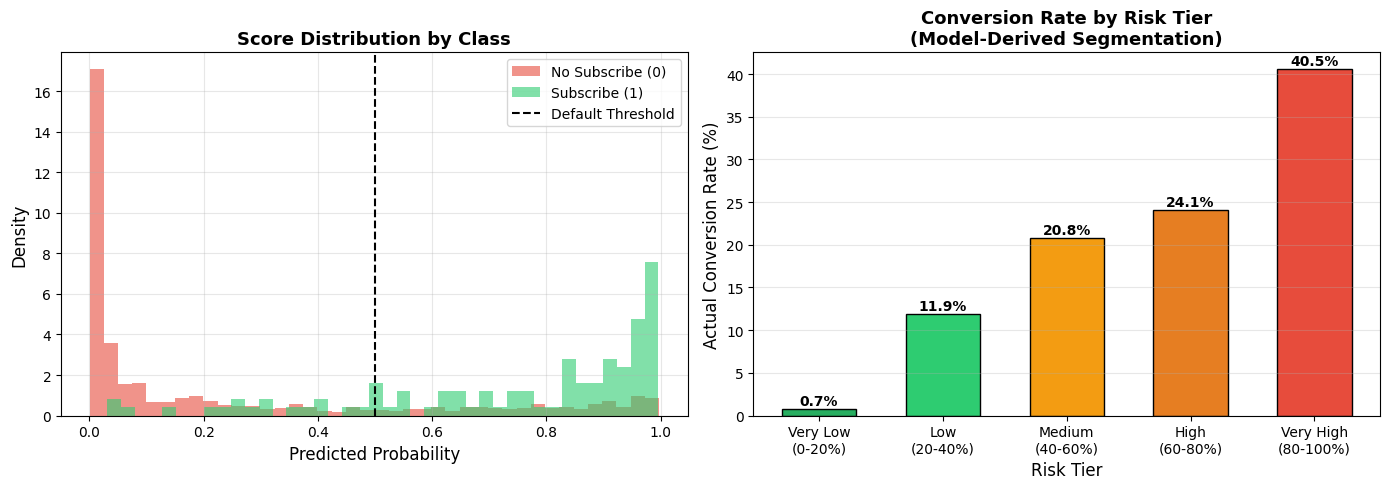


Conversion Rate by Risk Tier:
tier
Very Low\n(0-20%)        0.739372
Low\n(20-40%)           11.904762
Medium\n(40-60%)        20.754717
High\n(60-80%)          24.050633
Very High\n(80-100%)    40.540541


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by class
ax1 = axes[0]
ax1.hist(y_prob[y_test == 0], bins=40, alpha=0.6, color='#e74c3c', label='No Subscribe (0)', density=True)
ax1.hist(y_prob[y_test == 1], bins=40, alpha=0.6, color='#2ecc71', label='Subscribe (1)', density=True)
ax1.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Default Threshold')
ax1.set_xlabel('Predicted Probability', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Risk tiers
ax2 = axes[1]
risk_df = pd.DataFrame({'prob': y_prob, 'actual': y_test.values})
risk_df['tier'] = pd.cut(risk_df['prob'],
                         bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                         labels=['Very Low\n(0-20%)', 'Low\n(20-40%)',
                                 'Medium\n(40-60%)', 'High\n(60-80%)', 'Very High\n(80-100%)'])
tier_conv = risk_df.groupby('tier', observed=True)['actual'].mean() * 100
bars = ax2.bar(tier_conv.index, tier_conv.values,
               color=['#27ae60','#2ecc71','#f39c12','#e67e22','#e74c3c'],
               edgecolor='black', width=0.6)
for bar, val in zip(bars, tier_conv.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Risk Tier', fontsize=12)
ax2.set_ylabel('Actual Conversion Rate (%)', fontsize=12)
ax2.set_title('Conversion Rate by Risk Tier\n(Model-Derived Segmentation)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConversion Rate by Risk Tier:")
print(tier_conv.to_string())

In [ ]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC (Test)', 'ROC-AUC (5-Fold CV)',
               'F1 Score (Default θ=0.5)', f'F1 Score (Optimal θ={best_threshold:.2f})',
               'Precision', 'Recall', 'Avg Precision (PR-AUC)'],
    'Score': [
        f"{acc:.4f}",
        f"{roc:.4f}",
        f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}",
        f"{f1:.4f}",
        f"{best_f1:.4f}",
        f"{prec:.4f}",
        f"{rec:.4f}",
        f"{ap:.4f}"
    ],
    'Interpretation': [
        'Overall correct predictions',
        'Discrimination ability',
        'Generalization across folds — low variance = stable',
        'Balance between precision & recall',
        'Improved F1 with tuned decision boundary',
        'Out of all Yes predictions, how many were right',
        'Out of all actual Yes, how many were caught',
        'PR-AUC for imbalanced evaluation'
    ]
})

print(summary.to_string(index=False))

                   Metric           Score                                      Interpretation
                 Accuracy          0.7923                         Overall correct predictions
           ROC-AUC (Test)          0.8774                              Discrimination ability
      ROC-AUC (5-Fold CV) 0.9062 ± 0.0095 Generalization across folds — low variance = stable
 F1 Score (Default θ=0.5)          0.4778                  Balance between precision & recall
F1 Score (Optimal θ=0.83)          0.4856            Improved F1 with tuned decision boundary
                Precision          0.3359     Out of all Yes predictions, how many were right
                   Recall          0.8269         Out of all actual Yes, how many were caught
   Avg Precision (PR-AUC)          0.4086                    PR-AUC for imbalanced evaluation
